## Feature Engineering

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler, OneHotEncoder, FunctionTransformer
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import auc, roc_auc_score, classification_report, accuracy_score, recall_score, f1_score, confusion_matrix

import yaml
import optuna
import dagshub
import mlflow
import joblib

In [13]:
import sys
from pathlib import Path

#sys.path.append('')
PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

from src.transformers import MissingIndicatorTransformer


In [14]:
with open("../params.yaml") as f:
    parameters = yaml.safe_load(f)

DATA = parameters["data"]
FEATURES = parameters["features"]
MODEL = parameters["model"]

NUMERIC = FEATURES["numeric"]
CATEGORICAL = FEATURES["categorical"]
TARGET = FEATURES["target"]

In [15]:
df_train = pd.read_csv(f"{DATA['train_data']}")
df_test = pd.read_csv(f'{DATA["test_data"]}')

#### Split de los datos

In [16]:
X = df_train[NUMERIC + CATEGORICAL]
y = df_train[TARGET]

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state= 42, test_size = 0.2)

In [17]:
# Train
X_y_train = pd.concat([X_train, y_train], axis= 1)
X_y_train[TARGET].value_counts(normalize = True)

default_in_last_6months
0    0.94992
1    0.05008
Name: proportion, dtype: float64

In [18]:
# Test
X_y_test = pd.concat([X_test, y_test], axis= 1)
X_y_test[TARGET].value_counts(normalize = True)

default_in_last_6months
0    0.947617
1    0.052383
Name: proportion, dtype: float64

In [19]:
X_train_v2 = X_train.copy()
X_test_v2 = X_test.copy()
y_train_v2 = y_train.copy()
y_test_v2 = y_test.copy()

### Información proveniente del EDA

In [20]:
with open('./eda_output.txt', 'r') as f:
    eda = f.read()
print(eda)

=== Features Numéricas con Missings ===
- no_of_children (1.7%)
- no_of_days_employed (1.02%)
- yearly_debt_payments (0.21%)
- migrant_worker (0.19%)
- total_family_members (0.18%)
- credit_score (0.02%)

=== Features Categóricas con Missings ===
- owns_car (1.2%)

=== Reporte de Balanceamiento del Target ===
A nivel del dataset train tiene:
- 5% -> Default
- 95% -> No Default
Recomendación: Mirar Recall como kpi principal junto al AUC. Ponderar pesos entre default/nodefault

=== Reporte Feature vs Target ===
Se observa señal algunas señales fuertes que presuntamente indicarían poder predictivo relevante
Algunas de ellas son:
- prev_defaults
- credit_score
- credit_limit_used(%)
- credit_limit
- no_of_days_employed
- net_yearly_income
- gender

=== Reporte de Distribución de Features ===
Se observa que hay muchas features con sesgo hacia la derecha por naturaleza de la variable, 
por ello se recomienda aplicar una log-tranformation o el método WOE en al menos las siguientes:
- no_of_ch

In [21]:
class FeatureEngineering:
    def __init__(self):
        pass
    
    def binning_explore(self, dataset: pd.DataFrame, target: pd.Series, lista_feat: list):
        """Proporciona una tabla resumen de los features respecto a su distribución y event rate
        para hacer los binning manualmente"""
        dataset_merge = dataset.copy()
        dataset_merge["target"] = target
        lista_features = []

        for i in lista_feat:
            #feat = dataset_merge[i].value_counts(normalize = True)
            #event_rate = dataset_merge.groupby(i)["target"].mean()
            dataset_merge['bins'] = pd.qcut(
                x = dataset_merge[i],
                q = 5
            )
            eps = 1e-5
            table = dataset_merge.groupby(
                ['bins'], observed=False
            ).agg(
                total_obs = ("target", "count"),
                total_event = ("target", "sum"),
                event_rate = ("target", "mean")
            )
            table["pct_dist"] = table["total_obs"] / table["total_obs"].sum()
            table["total_no_event"] = table["total_obs"] - table["total_event"]
            table["dist_eventos"] = table["total_event"] / table["total_event"].sum()
            table["dist_no_eventos"] = table["total_no_event"] / table["total_no_event"].sum()
            table["woe"] = (
                np.log( (table["dist_no_eventos"] + eps) / (table["dist_eventos"] + eps) )
            )
            table["feature"] = i

            #table = pd.concat([df_feat, event_rate], axis= 1)
            table = table.reset_index()
            #table = table.sort_values(by=i, ascending= True)
            cols = ['feature'] + [col for col in table.columns if col != 'feature']
            table = table[cols]

            lista_features.append(table)

        return lista_features
    
    def bins_cut(self, dataset: pd.DataFrame, intervalos: list, labels: list, feature: str, target: str):
        """Crea los bins mediante pd.cut y devuelve un dataframe con las nuevas distribuciones y event rate"""
        dataset_merge = dataset.copy()
        
        intervalos_formato = intervalos[1:]
        epsilon = 1e-5

        dataset_merge["bins"] = pd.cut(
            dataset_merge[feature],
            bins= intervalos,
            labels= labels
        )

        agg = dataset_merge.groupby(
            "bins", observed=False
        ).agg(
            n_observaciones = (target, "count"),
            n_eventos = (target, "sum"),
        )
        
        agg["bad_rate"] = agg["n_eventos"] / agg["n_observaciones"]
        agg["pct_obs"] = agg["n_observaciones"] / agg["n_observaciones"].sum()
        agg["n_no_eventos"] = agg["n_observaciones"] - agg["n_eventos"]
        agg["dist_eventos"] = agg["n_eventos"] / agg["n_eventos"].sum()
        agg["dist_no_eventos"] = agg["n_no_eventos"] / agg["n_no_eventos"].sum()
        agg["woe"] = np.log(
            (agg["dist_no_eventos"] + epsilon) / (agg["dist_eventos"] + epsilon)
        )
        agg["iv"] = (agg["dist_no_eventos"] - agg["dist_eventos"]) * agg["woe"]

        table = pd.DataFrame({
            "feature": feature,
            "bin": range(len(agg)),
            "regla": intervalos_formato,
            "n_observaciones": agg["n_observaciones"],
            "pct_obs": agg["pct_obs"],
            "n_eventos": agg["n_eventos"],
            "n_no_eventos": agg["n_no_eventos"],
            "bad_rate": agg["bad_rate"],
            "dist_eventos": agg["dist_eventos"],
            "dist_no_eventos": agg["dist_no_eventos"],
            "WOE":  agg["woe"],
            "IV": agg["iv"]
        })

        print(f"IV del feature: {round(agg['iv'].sum(), 4)}")
        return table
    
    def binning_table(self, dataset: pd.DataFrame, target: pd.Series, feature_bin: str):
        """Proporciona una tabla resumen de los features respecto a su distribución y event rate"""
        dataset_merge = dataset.copy()
        dataset_merge["target"] = target

        eps = 1e-5
        table = dataset_merge.groupby(
            [feature_bin], observed=False
        ).agg(
            total_obs = ("target", "count"),
            total_event = ("target", "sum"),
            event_rate = ("target", "mean")
        )
        table["pct_dist"] = table["total_obs"] / table["total_obs"].sum()
        table["total_no_event"] = table["total_obs"] - table["total_event"]
        table["dist_eventos"] = table["total_event"] / table["total_event"].sum()
        table["dist_no_eventos"] = table["total_no_event"] / table["total_no_event"].sum()
        table["woe"] = (
            np.log( (table["dist_no_eventos"] + eps) / (table["dist_eventos"] + eps) )
        )
        table["feature"] = feature_bin

        #table = pd.concat([df_feat, event_rate], axis= 1)
        table = table.reset_index()
        #table = table.sort_values(by=i, ascending= True)
        cols = ['feature'] + [col for col in table.columns if col != 'feature']
        table = table[cols]

        return table

### Tratamiento de Missings

**Features Numéricas con Missings**
- no_of_children (1.7%) -> indicador de missing 
- no_of_days_employed (1.02%) -> se usará WOE
- yearly_debt_payments (0.21%) -> imputación mediana -> log-transformation
- migrant_worker (0.19%) -> imputación con 0 (valor dominante)
- total_family_members (0.18%) -> imputación mediana -> log-transformation
- credit_score (0.02%) -> se usará WOE

**Features Categóricas con Missings**
- owns_car (1.2%) -> crear categoría de missing

no_of_children (1.7%) -> indicador de missing -> imputación por 0 para Nan feat original

In [22]:
## HECHO POR FUERA (NO NECESARIO AHORA QUE SE INTEGRÓ AL PIPELINE DE SKLEARN CON FUNCIÓN)

# X_train['no_of_children_missing'] = X_train['no_of_children'].isna().astype(int)
# X_train.head()

owns_car (1.2%) -> Crear categoría MISSING

In [23]:
## TAMPOCO NECESARIO, SE INTEGRÓ AL PIPELINE DE MISSINGS
# X_train['owns_car'] = X_train['owns_car'].fillna('MISSING')

yearly_debt_payments, total_family_members, no_of_children -> imputación mediana


migrant_worker (0.19%) -> imputación con 0 (valor dominante)

In [24]:
## Se integrará al pipeline de sklearn
FEATS_IMPUTER_ZERO = ['no_of_children', 'migrant_worker']

### Log-Transformación

In [25]:
# Demostrativo, se integró al Pipeline de Sklearn

LOG_TRANSFORM = ['credit_limit', 'total_family_members', 'yearly_debt_payments', 'net_yearly_income']

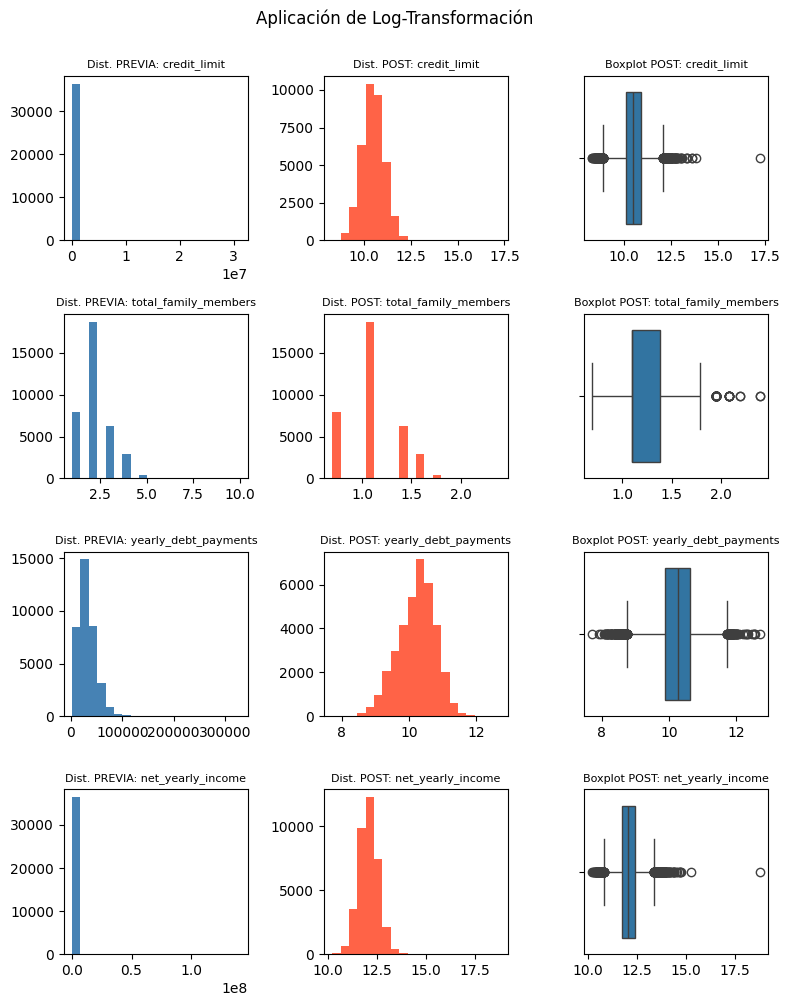

In [26]:
for i in LOG_TRANSFORM:
    X_train_v2[f'{i}_log'] = np.log1p(X_train_v2[i])

n_cols = 3
n_rows = ((len(LOG_TRANSFORM * 3) - 1) // 3 ) + 1
fig, axes = plt.subplots(ncols = n_cols, nrows = n_rows, figsize = (8, 2.5 * n_rows))

for i, feat in enumerate(LOG_TRANSFORM):
    axes[i, 0].hist(
        x = X_train_v2[feat],
        bins = 20,
        color = 'steelblue'
    )
    axes[i, 0].set_title(f'Dist. PREVIA: {feat}', fontsize = 8)

    axes[i, 1].hist(
        x = X_train_v2[f'{feat}_log'],
        bins = 20,
        color = 'tomato'
    )
    axes[i, 1].set_title(f'Dist. POST: {feat}', fontsize = 8)

    sns.boxplot(
        x = X_train_v2[f'{feat}_log'],
        ax = axes[i, 2]
    )
    axes[i, 2].set_title(f'Boxplot POST: {feat}', fontsize =8)
    axes[i, 2].set_xlabel('')

plt.suptitle('Aplicación de Log-Transformación', y = 1.001)
plt.tight_layout()
plt.show()

# sns.histplot(data = df_train, x = 'credit_limit_log')

### Aplicar la transformación WOE

In [27]:
## Aqui se aplica manualmente la creación de bins y su posterior cálculo del WOE
WOE_TRANSFORM = ['no_of_days_employed', 'credit_limit_used(%)', 'credit_score']

Binning Exploración

In [28]:
model_1 = FeatureEngineering()

In [29]:
bins_exploration = model_1.binning_explore(
    dataset = X_train_v2[WOE_TRANSFORM],
    target = y_train_v2,
    lista_feat = WOE_TRANSFORM
)
for i in bins_exploration:
    display(i)

,feature,bins,total_obs,total_event,event_rate,pct_dist,total_no_event,dist_eventos,dist_no_eventos,woe
0,no_of_days_employed,"(1.999, 747.0]",7227,516,0.071399,0.200410,6711,0.285556,0.195919,-0.376723
1,no_of_days_employed,"(747.0, 1609.0]",7200,441,0.061250,0.199662,6759,0.244051,0.197320,-0.212540
2,no_of_days_employed,"(1609.0, 3077.0]",7214,367,0.050873,0.200050,6847,0.203099,0.199889,-0.015931
3,no_of_days_employed,"(3077.0, 9120.0]",7208,252,0.034961,0.199884,6956,0.139458,0.203071,0.375773
4,no_of_days_employed,"(9120.0, 365252.0]",7212,231,0.032030,0.199994,6981,0.127836,0.203801,0.466365


,feature,bins,total_obs,total_event,event_rate,pct_dist,total_no_event,dist_eventos,dist_no_eventos,woe
0,credit_limit_used(%),"(-0.001, 21.0]",7425,0,0.000000,0.203860,7425,0.000000,0.214608,9.974029
1,credit_limit_used(%),"(21.0, 43.0]",7376,0,0.000000,0.202515,7376,0.000000,0.213192,9.967408
2,credit_limit_used(%),"(43.0, 65.0]",7352,0,0.000000,0.201856,7352,0.000000,0.212498,9.964149
3,credit_limit_used(%),"(65.0, 83.0]",7336,840,0.114504,0.201417,6496,0.460526,0.187757,-0.897192
4,credit_limit_used(%),"(83.0, 99.0]",6933,984,0.141930,0.190352,5949,0.539474,0.171946,-1.143372


,feature,bins,total_obs,total_event,event_rate,pct_dist,total_no_event,dist_eventos,dist_no_eventos,woe
0,credit_score,"(499.999, 689.0]",7316,1824,0.249317,0.200901,5492,1.0,0.158765,-1.840277
1,credit_score,"(689.0, 753.0]",7308,0,0.000000,0.200681,7308,0.0,0.211263,9.958320
2,credit_score,"(753.0, 818.0]",7302,0,0.000000,0.200516,7302,0.0,0.211089,9.957499
3,credit_score,"(818.0, 883.0]",7244,0,0.000000,0.198924,7244,0.0,0.209413,9.949524
4,credit_score,"(883.0, 949.0]",7246,0,0.000000,0.198978,7246,0.0,0.209470,9.949800


In [30]:
table_credit_limit_used = model_1.bins_cut(
    dataset = X_y_train,
    labels = ['<80%', '>80%'],
    intervalos = [-np.inf, 80 , np.inf],
    feature = 'credit_limit_used(%)',
    target = TARGET
    
)
table_credit_limit_used

IV del feature: 0.8388


,feature,bin,regla,n_observaciones,pct_obs,n_eventos,n_no_eventos,bad_rate,dist_eventos,dist_no_eventos,WOE,IV
bins,,,,,,,,,,,,
<80%,credit_limit_used(%),0,80.0,28177,0.773626,658,27519,0.023352,0.360746,0.795393,0.790648,0.343653
>80%,credit_limit_used(%),1,inf,8245,0.226374,1166,7079,0.141419,0.639254,0.204607,-1.139177,0.495140


In [31]:
table_credit_score = model_1.bins_cut(
    dataset = X_y_train,
    labels = ['<550', '>550'],
    intervalos = [-np.inf, 550, np.inf],
    #intervalos = [-np.inf, 499, 700, np.inf],
    feature = 'credit_score',
    target = TARGET
)
table_credit_score

IV del feature: 0.5545


,feature,bin,regla,n_observaciones,pct_obs,n_eventos,n_no_eventos,bad_rate,dist_eventos,dist_no_eventos,WOE,IV
bins,,,,,,,,,,,,
<550,credit_score,0,550.0,739,0.020293,352,387,0.476319,0.192982,0.011188,-2.846955,0.517562
>550,credit_score,1,inf,35677,0.979707,1472,34205,0.041259,0.807018,0.988812,0.203157,0.036933


**Transformación con WOE**

credit_limit_used(%)

In [39]:
# credit_limit_used(%) -> 0% missings
X_train_v2["credit_limit_used(%)_bin"] = pd.cut(
    x= X_train_v2['credit_limit_used(%)'],
    bins= [-np.inf, 80 , np.inf],
)

table = model_1.binning_table(
    dataset= X_train_v2,
    target = y_train_v2,
    feature_bin= 'credit_limit_used(%)_bin'
)

woe_map = dict(zip(table['credit_limit_used(%)_bin'], table['woe']))
X_train_v2['credit_limit_used(%)_woe'] = X_train_v2['credit_limit_used(%)_bin'].map(woe_map)

no_of_days_employed

In [41]:
# no_of_days_employed -> (1.02% missings)
X_train_v2["no_of_days_employed_bin"] = pd.cut(
    x= X_train_v2['no_of_days_employed'],
    bins= [-np.inf, 747, 1605, 3074, 9238, np.inf],
)
X_train_v2["no_of_days_employed_bin"] = X_train_v2["no_of_days_employed_bin"].astype(object)
X_train_v2.loc[X_train_v2["no_of_days_employed"].isna(), "no_of_days_employed_bin"] = "MISSING"

table_days_employed = model_1.binning_table(
    dataset= X_train_v2,
    target= y_train_v2,
    feature_bin= 'no_of_days_employed_bin'
)

woe_map = dict(zip(table_days_employed['no_of_days_employed_bin'], table_days_employed['woe']))
X_train_v2["no_of_days_employed_woe"] = X_train_v2['no_of_days_employed_bin'].map(woe_map)

In [55]:
# credit_score -> (0.02% missings)
X_train_v2["credit_score_bin"] = pd.cut(
    x= X_train_v2['credit_score'],
    bins= [-np.inf, 550, np.inf],
)

X_train_v2['credit_score_bin'] = X_train_v2['credit_score_bin'].astype(object)
X_train_v2.loc[X_train_v2['credit_score'].isna(), 'credit_score_bin'] = "MISSING"

table = model_1.binning_table(
    dataset= X_train_v2,
    target = y_train_v2,
    feature_bin= 'credit_score_bin'
)

woe_map = dict(zip(table['credit_score_bin'], table['woe']))
X_train_v2['credit_score_woe'] = X_train_v2['credit_score_bin'].map(woe_map)

In [56]:
woe_map

{Interval(-inf, 550.0, closed='right'): -2.8471286788969086,
 Interval(550.0, inf, closed='right'): 0.20298355025038262,
 'MISSING': 2.9091958506277895}

#### Guardar Reglas de WOE

In [57]:
woe_bins = {
    'credit_limit_used(%)': {
        'bins': [-np.inf, 80 , np.inf],
        'woe_values': [
            0.7906478899247511,
            -1.139177188570777
        ]
    },
    'no_of_days_employed': {
        'bins': [-np.inf, 747, 1605, 3074, 9238, np.inf],
        'woe_values': [
            -0.3773512959724896,
            -0.2094547683884873,
            -0.023240524513818788,
            0.3738304511540686,
            0.46940540571615036
        ],
        'missing_woe': 0.06459721243849813
    },
    'credit_score': {
        'bins': [-np.inf, 550, np.inf],
        'woe_values': [
            -2.8471286788969086,
            0.20298355025038262
        ],
        'missing_woe': 2.9091958506277895
    }
}

joblib.dump(woe_bins, '../artifacts/encoders/woe_bins.pkl')

['../artifacts/encoders/woe_bins.pkl']

#### Agregando Missing Indicator como función interna del pipeline

In [151]:
## Se creó una clase en /src/transformers.py

### Pipeline finales

In [93]:
FEATS_NUM_WOE = ['credit_limit_used(%)_woe', 'no_of_days_employed_woe', 'credit_score_woe'] # solo agregar
FEATS_NUM_LOG_TRANS = ['credit_limit', 'total_family_members', 'yearly_debt_payments', 'net_yearly_income'] # Sin crear aún - check
FEATS_CATEGORICALS = ['gender', 'owns_car', 'owns_house', 'occupation_type'] # check

# Indicator missing
FEATS_MISSINGS = ['no_of_children_missing'] # HECHO POR FUERA
FEATS_MISSINGS_SKLEARN = ['no_of_children'] # HECHO PARA INTEGRARSE AL PIPELINE SKLEARN

FEATS_NUM_IMP_ZERO = ['migrant_worker'] # check
FEATS_NUM_IMP_ZERO_SCALING = ['no_of_children'] # check
FEATS_OTROS_NUM_SCALING = ['age'] 
FEATS_OTROS_BINARY = ['prev_defaults']

In [11]:
df_train['occupation_type'].value_counts()

occupation_type
Unknown                  14299
Laborers                  8134
Sales staff               4725
Core staff                4062
Managers                  3168
Drivers                   2747
High skill tech staff     1682
Accountants               1474
Medicine staff            1275
Security staff            1025
Cooking staff              902
Cleaning staff             665
Private service staff      387
Low-skill Laborers         336
Waiters/barmen staff       203
Secretaries                199
Realty agents              101
HR staff                    78
IT staff                    66
Name: count, dtype: int64

#### Pipeline TRAIN

In [172]:
pipe_num_median_logtrans = Pipeline(
    steps= [
        ('imputer_median', SimpleImputer(strategy = 'median')),
        # omitir por ahora tratamiento de outliers
        ('log_transformation', FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
        ('standar_scaler', StandardScaler())
    ]
)

pipe_num_zero = Pipeline(
    steps = [
        ('imputer_zero', SimpleImputer(strategy = 'constant', fill_value = 0))
    ]
)

pipe_num_missing_ind = Pipeline(
    steps = [
        ('missing_indicator', MissingIndicatorTransformer(columns= FEATS_MISSINGS_SKLEARN))
    ]
)

pipe_num_zero_scaling = Pipeline(
    steps = [
        ('imputer_zero', SimpleImputer(strategy = 'constant', fill_value = 0)),
        ('standar_scaler', StandardScaler())
    ]
)

pipe_encoding = Pipeline(
    steps = [
        ("imputer", SimpleImputer(strategy="constant", fill_value="MISSING")),
        ('ohe', OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ]
)

pipe_num_otros_scaling = Pipeline(
    steps = [
        ('standar_scaler', StandardScaler())
    ]
)

# preprocessor = ColumnTransformer(
#     transformers = [
#         ('num_median_logtrans', pipe_num_median_logtrans, FEATS_NUM_LOG_TRANS),
#         ('num_zero', pipe_num_zero, FEATS_NUM_IMP_ZERO),
#         ('num_zero_scaling', pipe_num_zero_scaling, FEATS_NUM_IMP_ZERO_SCALING),
#         ('ohe_encoder', pipe_encoding, FEATS_CATEGORICALS),
#         ('num_otros_scaling', pipe_num_otros_scaling, FEATS_OTROS_NUM_SCALING),
#         ('woe', 'passthrough', FEATS_NUM_WOE),
#         ('missing', pipe_num_missing_ind),
#         ('binary', 'passthrough', FEATS_OTROS_BINARY)
#     ]
# )

preprocessor = Pipeline(
    steps= [
        ('missing_indicator', MissingIndicatorTransformer(columns= FEATS_MISSINGS_SKLEARN)),
        ('column_transform', ColumnTransformer(
    transformers = [
        ('num_median_logtrans', pipe_num_median_logtrans, FEATS_NUM_LOG_TRANS),
        ('num_zero', pipe_num_zero, FEATS_NUM_IMP_ZERO),
        ('num_zero_scaling', pipe_num_zero_scaling, FEATS_NUM_IMP_ZERO_SCALING),
        ('ohe_encoder', pipe_encoding, FEATS_CATEGORICALS),
        ('num_otros_scaling', pipe_num_otros_scaling, FEATS_OTROS_NUM_SCALING),
        ('woe', 'passthrough', FEATS_NUM_WOE),
        ('missing', 'passthrough', FEATS_MISSINGS),
        ('binary', 'passthrough', FEATS_OTROS_BINARY)
    ]
))
    ]
)


# model_pipeline = Pipeline(
#     steps = [
#         ('preprocessor', preprocessor),
#         ('model', LogisticRegression(
#             max_iter = 1000,
#             class_weight= 'balanced',
#             random_state = 42
#         ))
#     ]
# )

In [133]:
X_train_clean = X_train_v2[FEATS_NUM_WOE + FEATS_NUM_LOG_TRANS + FEATS_CATEGORICALS + FEATS_NUM_IMP_ZERO + FEATS_NUM_IMP_ZERO_SCALING + FEATS_OTROS_NUM_SCALING + FEATS_OTROS_BINARY]
y_train_clean = y_train_v2
X_train_clean

,credit_limit_used(%)_woe,no_of_days_employed_woe,credit_score_woe,credit_limit,total_family_members,yearly_debt_payments,net_yearly_income,gender,owns_car,owns_house,occupation_type,migrant_worker,no_of_children,age,prev_defaults
23601,0.790648,-0.023241,0.202984,26259.37,2.0,18026.60,145945.32,F,Y,N,Sales staff,0.0,0.0,46,0
7665,-1.139177,0.373830,0.202984,8049.49,3.0,23525.56,64709.80,F,N,N,Sales staff,0.0,1.0,49,0
11617,0.790648,-0.209455,0.202984,65553.16,1.0,47257.16,179486.97,F,N,Y,Cooking staff,0.0,0.0,23,0
14326,0.790648,-0.377351,0.202984,17414.96,4.0,20127.91,108003.38,M,N,Y,Security staff,0.0,2.0,34,0
27486,0.790648,-0.023241,0.202984,20696.95,2.0,38894.48,127264.91,M,Y,Y,Laborers,1.0,0.0,42,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,0.790648,0.469405,0.202984,33549.89,2.0,27792.70,128089.29,F,N,Y,Unknown,0.0,0.0,24,0
44732,0.790648,0.373830,0.202984,24660.55,3.0,54258.29,175825.98,F,N,Y,Medicine staff,0.0,1.0,49,0
38158,-1.139177,-0.209455,0.202984,80521.11,2.0,30470.78,314615.77,F,N,Y,Accountants,0.0,0.0,41,0
860,0.790648,0.373830,0.202984,77568.61,2.0,26381.19,324914.57,F,N,Y,Laborers,0.0,0.0,27,0


#### Pipeline TEST

In [46]:
X_test.head()

,age,no_of_children,net_yearly_income,no_of_days_employed,total_family_members,migrant_worker,yearly_debt_payments,credit_limit,credit_limit_used(%),credit_score,prev_defaults,gender,owns_car,owns_house,occupation_type
34126,50,0.0,269502.14,4181.0,1.0,0.0,17440.44,36017.45,23,807.0,0,F,N,Y,Unknown
44609,29,0.0,115795.25,365250.0,2.0,0.0,28962.21,21781.38,60,858.0,0,F,N,Y,Unknown
44264,39,0.0,113477.67,365241.0,2.0,0.0,27463.96,27485.15,81,667.0,0,F,N,Y,Unknown
33556,35,1.0,215555.19,1882.0,3.0,0.0,47863.75,25054.25,32,690.0,0,F,Y,Y,Managers
28050,53,0.0,185082.22,365244.0,2.0,0.0,47185.73,65186.23,65,721.0,0,M,Y,Y,Unknown


WOE

In [62]:
# credit_limit_used(%) -> 0% missings
X_test_v2["credit_limit_used(%)_woe"] = pd.cut(
    x= X_test_v2['credit_limit_used(%)'],
    bins= woe_bins['credit_limit_used(%)']['bins'],
    labels= woe_bins['credit_limit_used(%)']['woe_values']
).astype(float)

In [53]:
# no_of_days_employed -> (1.02% missings)
X_test_v2["no_of_days_employed_woe"] = pd.cut(
    x= X_test_v2['no_of_days_employed'],
    bins= woe_bins['no_of_days_employed']['bins'],
    labels= woe_bins['no_of_days_employed']['woe_values']
).astype(float)

X_test_v2.loc[X_test_v2['no_of_days_employed'].isna(), 'no_of_days_employed_woe'] = woe_bins['no_of_days_employed']['missing_woe']


In [60]:
# credit_score -> (0.02% missings)
X_test_v2["credit_score_woe"] = pd.cut(
    x= X_test_v2['credit_score'],
    bins= woe_bins['credit_score']['bins'],
    labels= woe_bins['credit_score']['woe_values']
).astype(float)

X_test_v2.loc[X_test_v2['credit_score'].isna(), 'credit_score_woe'] = woe_bins['credit_score']['missing_woe']


In [137]:
X_test_clean = X_test_v2[
    FEATS_NUM_WOE 
    + FEATS_NUM_LOG_TRANS 
    + FEATS_CATEGORICALS  
    + FEATS_NUM_IMP_ZERO 
    + FEATS_NUM_IMP_ZERO_SCALING 
    + FEATS_OTROS_NUM_SCALING 
    + FEATS_OTROS_BINARY
]

FEATS_NUM_WOE + FEATS_NUM_LOG_TRANS + FEATS_CATEGORICALS + FEATS_NUM_IMP_ZERO + FEATS_NUM_IMP_ZERO_SCALING + FEATS_OTROS_NUM_SCALING + FEATS_OTROS_BINARY

y_test_clean = y_test_v2

### Registrar experimento en MLFlow

In [108]:
dagshub.init(repo_owner='davidrodriguez2712', repo_name='proyecto-3-riesgo-crediticio', mlflow=True)


Initialized MLflow to track repo "davidrodriguez2712/proyecto-3-riesgo-crediticio"

Repository davidrodriguez2712/proyecto-3-riesgo-crediticio initialized!

In [109]:
mlflow.set_tracking_uri('https://dagshub.com/davidrodriguez2712/proyecto-3-riesgo-crediticio.mlflow')


In [110]:
mlflow.create_experiment(name= 'Proyecto_3_riesgo_credito')
mlflow.set_experiment(experiment_name= 'Proyecto_3_riesgo_credito')

<Experiment: artifact_location='mlflow-artifacts:/a6c5ecb911f8453daf1b24b248c6b22c', creation_time=1777748161120, experiment_id='2', last_update_time=1777748161120, lifecycle_stage='active', name='Proyecto_3_riesgo_credito', tags={}, trace_location=None, workspace='default'>

In [113]:
preprocessor

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('missing_indicator', ...), ('column_transform', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,columns,['no_of_children']
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num_median_logtrans', ...), ('num_zero', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_thres

#### Registrando los artefactos de 02_Feature_Engineering

In [174]:
with mlflow.start_run(run_name = '02_feature_engineering') as run:
    # Preprocessor
    joblib.dump(preprocessor, '../artifacts/preprocessors/preprocessor.pkl')
    mlflow.log_artifact('../artifacts/preprocessors/preprocessor.pkl')

    # Splits
    X_train.to_parquet('../data/splits/X_train.parquet')
    X_test.to_parquet('../data/splits/X_test.parquet')
    y_train.to_frame(name= TARGET).to_parquet('../data/splits/y_train.parquet')
    y_test.to_frame(name = TARGET).to_parquet('../data/splits/y_test.parquet')
    mlflow.log_artifact('../data/splits/X_train.parquet')
    mlflow.log_artifact('../data/splits/X_test.parquet')
    mlflow.log_artifact('../data/splits/y_train.parquet')
    mlflow.log_artifact('../data/splits/y_test.parquet')

    # Features manuales (antes del preprocessor)
    X_train_clean.to_parquet('../data/features/X_train_woe.parquet')
    X_test_clean.to_parquet('../data/features/X_test_woe.parquet')
    y_train_clean.to_frame(name= TARGET).to_parquet('../data/features/y_train_woe.parquet')
    y_test_clean.to_frame(name= TARGET).to_parquet('../data/features/y_test_woe.parquet')
    mlflow.log_artifact('../data/features/X_train_woe.parquet')
    mlflow.log_artifact('../data/features/X_test_woe.parquet')
    mlflow.log_artifact('../data/features/y_train_woe.parquet')
    mlflow.log_artifact('../data/features/y_test_woe.parquet')

    # Reglas (WOE)
    joblib.dump(woe_bins, '../artifacts/encoders/woe_bins.pkl')
    mlflow.log_artifact('../artifacts/encoders/woe_bins.pkl')
    

🏃 View run 02_feature_engineering at: https://dagshub.com/davidrodriguez2712/proyecto-3-riesgo-crediticio.mlflow/#/experiments/2/runs/ee918f05c79f447c89728fc5ecaf6af3
🧪 View experiment at: https://dagshub.com/davidrodriguez2712/proyecto-3-riesgo-crediticio.mlflow/#/experiments/2
